In [ ]:
import numpy as np
import pandas as pd
from numba import njit
from datetime import datetime
import talib
import vectorbt as vbt
from vectorbt.indicators.factory import IndicatorFactory

from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

#My other files
from Data_Handling import get_data_auto, fetch_alpaca_vbt_data
from Alpaca_Credentials import ALPACA_API_KEY, ALPACA_SECRET_KEY
client = StockHistoricalDataClient(ALPACA_API_KEY, ALPACA_SECRET_KEY)


import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter
from itertools import product
import optuna


# Data Handling

Working perfectly! (might need to reformat for multi index data)

In [2]:
# Fetch price data
symbol = "AAPL"
start = "2023-01-01"
end = "2024-01-01"
df = get_data_auto(symbol, start, end, timeframe_unit="Day")

In [3]:
df = vbt.YFData.download("AAPL", start="2023-01-01", end="2024-01-01")

# Access OHLCV as NumPy
close = df.get("Close")  # pandas Series
close_np = close.values  # NumPy

# Plot
close.vbt.plot()


FigureWidget({
    'data': [{'name': 'Close',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'f4dc1d8d-2270-44b8-beaf-b6439082539b',
              'x': array([datetime.datetime(2023, 1, 3, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 1, 4, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 1, 5, 5, 0, tzinfo=datetime.timezone.utc), ...,
                          datetime.datetime(2023, 12, 27, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 12, 28, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 12, 29, 5, 0, tzinfo=datetime.timezone.utc)],
                         dtype=object),
              'y': array([123.47061157, 124.74412537, 123.42125702, ..., 191.74583435,
                          192.17269897, 191.13031006])}],
    'layout': {'height': 350,
               'legend': {'orientation': 

In [4]:
df = fetch_alpaca_vbt_data("AAPL", "2023-01-01", "2024-01-01", timeframe_unit="Hour", multiplier=1)

# Access OHLCV as NumPy
close = df.get("Close")  # pandas Series
close_np = close.values  # NumPy

# Plot
close.vbt.plot()

FigureWidget({
    'data': [{'name': 'Close',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'e8a81669-8d82-426d-b248-940109b1a38e',
              'x': array([datetime.datetime(2023, 1, 3, 9, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 1, 3, 10, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 1, 3, 11, 0, tzinfo=TzInfo(UTC)), ...,
                          datetime.datetime(2023, 12, 29, 22, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 12, 29, 23, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 12, 30, 0, 0, tzinfo=TzInfo(UTC))], dtype=object),
              'y': array([131.3   , 131.    , 130.38  , ..., 192.26  , 192.1894, 192.1501])}],
    'layout': {'height': 350,
               'legend': {'orientation': 'h',
                          'traceorder': 'normal',
                          'x': 1,
                          'xanchor': 'righ

In [5]:
df = get_data_auto("AAPL", "2023-01-01", "2024-01-01", timeframe_unit="Hour", multiplier=1)

# Access OHLCV as NumPy
close = df.get("Close")  # pandas Series
close_np = close.values  # NumPy

# Plot
close.vbt.plot()

FigureWidget({
    'data': [{'name': 'Close',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'dde1bb8c-5c7f-4418-a0b5-5096edbaef78',
              'x': array([datetime.datetime(2023, 1, 3, 9, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 1, 3, 10, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 1, 3, 11, 0, tzinfo=TzInfo(UTC)), ...,
                          datetime.datetime(2023, 12, 29, 22, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 12, 29, 23, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 12, 30, 0, 0, tzinfo=TzInfo(UTC))], dtype=object),
              'y': array([131.3   , 131.    , 130.38  , ..., 192.26  , 192.1894, 192.1501])}],
    'layout': {'height': 350,
               'legend': {'orientation': 'h',
                          'traceorder': 'normal',
                          'x': 1,
                          'xanchor': 'righ

In [6]:
df = get_data_auto("AAPL", "2023-01-01", "2024-01-01", timeframe_unit="Day", multiplier=1)

# Access OHLCV as NumPy
close = df.get("Close")  # pandas Series
close_np = close.values  # NumPy

# Plot
close.vbt.plot()

FigureWidget({
    'data': [{'name': 'Close',
              'showlegend': True,
              'type': 'scatter',
              'uid': '8b7275a9-85e0-4ca4-9d79-414b72dc7263',
              'x': array([datetime.datetime(2023, 1, 3, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 1, 4, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 1, 5, 5, 0, tzinfo=datetime.timezone.utc), ...,
                          datetime.datetime(2023, 12, 27, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 12, 28, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 12, 29, 5, 0, tzinfo=datetime.timezone.utc)],
                         dtype=object),
              'y': array([123.47061157, 124.74412537, 123.42125702, ..., 191.74583435,
                          192.17269897, 191.13031006])}],
    'layout': {'height': 350,
               'legend': {'orientation': 

In [7]:
df= get_data_auto("AAPL", "2023-01-01", "2024-01-01", timeframe_unit="Day", multiplier=1)

# Plot 
df.vbt.ohlcv.plot()


FigureWidget({
    'data': [{'close': array([123.47061157, 124.74412537, 123.42125702, ..., 191.74583435,
                              192.17269897, 191.13031006]),
              'decreasing': {'line': {'color': '#d95f02'}},
              'high': array([129.22605214, 127.01471628, 126.13609037, ..., 192.09329598,
                             193.24484932, 192.98671035]),
              'increasing': {'line': {'color': '#1b9e76'}},
              'low': array([122.58211922, 123.48049504, 123.16458729, ..., 189.70081254,
                            191.76567599, 190.33612301]),
              'name': 'OHLC',
              'open': array([128.61398548, 125.26734659, 125.50427521, ..., 191.09064392,
                             192.72862542, 192.49034534]),
              'type': 'ohlc',
              'uid': '5b2a4622-99d8-4160-b800-ad2c303f7ddd',
              'x': array([datetime.datetime(2023, 1, 3, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 1, 4,

In [8]:
df= get_data_auto("AAPL", "2023-01-01", "2024-01-01", timeframe_unit="Hour", multiplier=1)

# Plot 
df.vbt.ohlcv.plot()

FigureWidget({
    'data': [{'close': array([131.3   , 131.    , 130.38  , ..., 192.26  , 192.1894, 192.1501]),
              'decreasing': {'line': {'color': '#d95f02'}},
              'high': array([131.46  , 131.4   , 131.25  , ..., 192.53  , 192.2599, 192.24  ]),
              'increasing': {'line': {'color': '#1b9e76'}},
              'low': array([130.28, 130.8 , 130.05, ..., 192.  , 192.13, 192.1 ]),
              'name': 'OHLC',
              'open': array([130.28  , 131.4   , 130.91  , ..., 192.3702, 192.2599, 192.14  ]),
              'type': 'ohlc',
              'uid': '6d0c4297-96c9-4a72-9b07-f9ff667bef84',
              'x': array([datetime.datetime(2023, 1, 3, 9, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 1, 3, 10, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 1, 3, 11, 0, tzinfo=TzInfo(UTC)), ...,
                          datetime.datetime(2023, 12, 29, 22, 0, tzinfo=TzInfo(UTC)),
                          date

In [9]:
df_day = get_data_auto("AAPL", "2023-01-01", "2023-06-01", timeframe_unit="Day")
df_hour = get_data_auto("AAPL", "2023-01-01", "2023-06-01", timeframe_unit="Hour", multiplier=1)

# Shape
print("SHAPES:")
print("Day:", df_day.shape)
print("Hour:", df_hour.shape)

# Columns
print("\nCOLUMNS:")
print("Day:", df_day.columns)
print("Hour:", df_hour.columns)

# Dtypes
print("\nDTYPES:")
print("Day:\n", df_day.dtypes)
print("Hour:\n", df_hour.dtypes)

# Index type and name
print("\nINDEX TYPE AND NAME:")
print("Day:", type(df_day.index), df_day.index.name)
print("Hour:", type(df_hour.index), df_hour.index.name)

# Columns name
print("\nCOLUMNS NAME:")
print("Day:", df_day.columns.name)
print("Hour:", df_hour.columns.name)

# Head preview
print("\nHEAD (Day):\n", df_day.head())
print("\nHEAD (Hour):\n", df_hour.head())

#They are Identical, just different timeframes
print("After checking print statements, they are identical")

SHAPES:
Day: (103, 5)
Hour: (1608, 5)

COLUMNS:
Day: Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object', name='field')
Hour: Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object', name='field')

DTYPES:
Day:
 field
Open      float64
High      float64
Low       float64
Close     float64
Volume    float64
dtype: object
Hour:
 field
Open      float64
High      float64
Low       float64
Close     float64
Volume    float64
dtype: object

INDEX TYPE AND NAME:
Day: <class 'pandas.core.indexes.datetimes.DatetimeIndex'> timestamp
Hour: <class 'pandas.core.indexes.datetimes.DatetimeIndex'> timestamp

COLUMNS NAME:
Day: field
Hour: field

HEAD (Day):
 field                            Open        High         Low       Close  \
timestamp                                                                   
2023-01-03 05:00:00+00:00  128.613985  129.226052  122.582119  123.470612   
2023-01-04 05:00:00+00:00  125.267347  127.014716  123.480495  124.744125   
2023-01-05 05:00:0

# Indicators/Strategies, Portfolios and Order types

## Basic Indicators


In [10]:
# There are many many more indicators available in TA-Lib

# Access OHLCV as NumPy
close = df["Close"].values.astype(np.float64)

# Various Basic indicators:
sma_20 = talib.SMA(close, timeperiod=20).astype(np.float32)
#sma_ind = vbt.IndicatorFactory.from_talib("SMA")


ema_20 = talib.EMA(close, timeperiod=20).astype(np.float32)
#ema_ind = vbt.IndicatorFactory.from_talib("EMA")

rsi_14 = talib.RSI(close, timeperiod=14).astype(np.float32)
#rsi_ind = vbt.IndicatorFactory.from_talib("RSI")


macd, macd_signal, macd_hist = [x.astype(np.float32) for x in talib.MACD(close)]

bb_middle, bb_upper, bb_lower = [x.astype(np.float32) for x in talib.BBANDS(
    close, timeperiod=20, nbdevup=2.0, nbdevdn=2.0, matype=0)]


### Basic RSI Indicator/Strategy and Optimization

In [11]:
# Calculating RSI Indicator; 
rsi_values = talib.RSI(df['Close'].values, timeperiod=14) 

# PLotting RSI Indicator
rsi_series = pd.Series(rsi_values, index=df.index, name="RSI")
rsi_series.vbt.plot(title=f"{symbol} RSI (14)", yaxis_title="RSI")

FigureWidget({
    'data': [{'name': 'RSI',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'c94ff76c-d70e-4660-ab19-e6a99bd36503',
              'x': array([datetime.datetime(2023, 1, 3, 9, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 1, 3, 10, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 1, 3, 11, 0, tzinfo=TzInfo(UTC)), ...,
                          datetime.datetime(2023, 12, 29, 22, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 12, 29, 23, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 12, 30, 0, 0, tzinfo=TzInfo(UTC))], dtype=object),
              'y': array([        nan,         nan,         nan, ..., 35.22838005, 34.34556285,
                          33.83723315])}],
    'layout': {'height': 350,
               'legend': {'orientation': 'h',
                          'traceorder': 'normal',
                          'x': 1,


In [12]:
# Single Case RSI
rsi_values = talib.RSI(df['Close'].values, 14) 

# Define the signals based on continuous logic:
signals= np.where(rsi_values < 30, 1, 0) 
signals= np.where(rsi_values > 70, -1, signals)

entries = signals == 1
exits = signals == -1

pf = vbt.Portfolio.from_signals(
    close = df['Close'],
    entries=entries,
    exits=exits,
    init_cash=10000,
    fees=0.001,
    slippage=0.001
)
print(pf.total_return())
pf.plot().show()


0.1094340653569383


In [13]:
# RSI Strategy (not efficently computed, ony ticker max, no timeframes):

#Define the RSI strategy logic:
def rsi_strategy(close, rsi_period=14, entry_threshold=30, exit_threshold=70): 
    # Calculate RSI, if we use vbt fuunction we can use @njit compilation
    rsi = talib.RSI(close.flatten(), rsi_period) 

    # Define the signals based on continuous logic:
    signals= np.where(rsi < entry_threshold, 1, 0) 
    signals= np.where(rsi > exit_threshold, -1, signals)
    return signals


# Define RSI strategy function for vbt compatability
rsi_ind1 = IndicatorFactory(
    class_name="RSIStrategy1",
    short_name="RSI",
    input_names=["close"],
    param_names=["rsi_period", "entry_threshold", "exit_threshold"],
    output_names=["signals"],
    ).from_apply_func(
        rsi_strategy,
        rsi_period=14,
        entry_threshold=30,
        exit_threshold=70,
        )

# Runnning the strategy with single parameterization
res = rsi_ind1.run(
    close=df['Close'],
    rsi_period=14,
    entry_threshold=30,
    exit_threshold=70,
)

# Outputting the results
pf = vbt.Portfolio.from_signals(
    close=df['Close'],
    entries=res.signals == 1.0,
    exits=res.signals == -1.0,
    size=1,
    fees=0.001,
    slippage=0.001,
    )


pf.total_return()


0.10943406535693924

## Custom Indicator/Strategy!!!
(with RAM reduction techniques and numby complied for max computational efficiency)

In [14]:
@njit # Just-in-time compilation for performance
def custom_signal_logic(short_ema, med_ema, long_ema):
    # Define the signals based on continuous logic:
    signals = np.where((short_ema > med_ema) & (med_ema > long_ema), 1, 0) 
    signals = np.where(short_ema < med_ema, -1, signals)
    return signals

def custom_indicator(close, short_ema=12, med_ema=26, long_ema=50):
    s_ema = vbt.IndicatorFactory.from_talib("EMA").run(close, timeperiod=short_ema).real.to_numpy()
    m_ema = vbt.IndicatorFactory.from_talib("EMA").run(close, timeperiod=med_ema).real.to_numpy()
    l_ema = vbt.IndicatorFactory.from_talib("EMA").run(close, timeperiod=long_ema).real.to_numpy()
    return custom_signal_logic(s_ema, m_ema, l_ema)

# Define RSI strategy function for vbt compatability
custom1 = IndicatorFactory(
    class_name="CustomStrategy",
    short_name="Custom",
    input_names=["close"],
    param_names=["short_ema", "med_ema", "long_ema"],
    output_names=["signals"],
    ).from_apply_func(
        custom_indicator,
        short_ema=12,
        med_ema=26,
        long_ema=50,
        )

# Runnning the strategy with single parameterization
res_cus1 = custom1.run(
    close=df['Close'],
    short_ema=12,
    med_ema=26,
    long_ema=50,
    )

# Outputting the results
pf2 = vbt.Portfolio.from_signals(
    close=df['Close'],
    entries=res_cus1.signals == 1.0,
    exits=res_cus1.signals == -1.0,
    size=1,
    fees=0.001,
    slippage=0.001,
    )


pf2.total_return()



0.12062398528292291

## Using Order types

In [15]:
@njit # Just-in-time compilation for performance
def custom_signal_logic2(close, ema, rsi, entries, exits):
    # Define the signals based on continuous logic:
    signals = np.where((rsi < entries) & (close > ema), 1, 0)
    signals = np.where(rsi > exits, -1, signals)
    return signals

def custom_indicator2(close, ema=12, period=14, entries=30, exits=70, sl_trail=0.05, tp_stop=0.1, sl_stop=0.05):
    ema_vals = vbt.IndicatorFactory.from_talib("EMA").run(close, ema).real.to_numpy() 
    rsi_vals = vbt.IndicatorFactory.from_talib("RSI").run(close, period).real.to_numpy()
    return custom_signal_logic2(close, ema_vals, rsi_vals, entries, exits), np.broadcast_to(sl_trail, close.shape), np.broadcast_to(tp_stop, close.shape), np.broadcast_to(sl_stop, close.shape)

# Define RSI strategy function for vbt compatability
custom2 = IndicatorFactory(
    class_name="CustomStrategy2",
    short_name="Custom2",
    input_names=["close"],
    param_names=["ema", "period", "entries", "exits", "sl_trail", "tp_stop", "sl_stop"],
    output_names=["signals", "sl_trail", "tp_stop", "sl_stop"],
    ).from_apply_func(
        custom_indicator2)

# Runnning the strategy with single parameterization
res_cus2 = custom2.run(
    close=df['Close'],
    ema=12,
    period=14,
    entries=30,
    exits=70,
    sl_trail=0.05,
    tp_stop=0.1,
    sl_stop=0.05,
    )

# Outputting the results
pf3 = vbt.Portfolio.from_signals(
    close=df['Close'],
    entries=res_cus2.signals == 1.0,
    exits=res_cus2.signals == -1.0,
    size=1,
    fees=0.001,
    slippage=0.001,
    sl_stop=res_cus2.sl_stop, # 5% stop loss
    tp_stop=res_cus2.tp_stop, # 10% take profit
    sl_trail=res_cus2.sl_trail # 5% trailing stop loss
    )

pf3.total_return()


0.02399636450265888

# Optimisation and Overfitting

## Optimising 

### Optimising Basic RSI

In [16]:
# Runnning the strategy with multi parameterization
rsi_periods = list(range(14, 29, 1))           
entry_thresholds = list(range(5, 36, 1))      
exit_thresholds = list(range(50, 81, 1)) 

res2opt = rsi_ind1.run(
    close=df['Close'],
    rsi_period=rsi_periods,
    entry_threshold=entry_thresholds,
    exit_threshold=exit_thresholds,
    param_product=True
)

pf_opt = vbt.Portfolio.from_signals(
    close=df['Close'],
    entries=res2opt.signals == 1.0,
    exits=res2opt.signals == -1.0,
    size=1,
    fees=0.001,
    slippage=0.001,
    )


print(pf_opt.total_return())
print(pf_opt.total_return().shape[0])
print(max(pf_opt.total_return()))

RSI_rsi_period  RSI_entry_threshold  RSI_exit_threshold
14              5                    50                    0.000000
                                     51                    0.000000
                                     52                    0.000000
                                     53                    0.000000
                                     54                    0.000000
                                                             ...   
28              35                   76                    0.456845
                                     77                    0.463607
                                     78                    0.469157
                                     79                    0.519905
                                     80                    0.519905
Name: total_return, Length: 14415, dtype: float64
14415
0.5672884919684634


In [17]:
returns = pf_opt.total_return()
# If i wanna collapse an axis to a single value by taking the mean
#returns = returns.groupby(level=["RSI_entry_threshold", "RSI_exit_threshold"]).mean()

# # Plotting 2D heatmap with slider
fig = returns.vbt.heatmap(
    x_level="RSI_entry_threshold",
    y_level="RSI_exit_threshold",
    slider_level="RSI_rsi_period",
    title="RSI Strategy Returns",
    xaxis_title="Entry Threshold",
    yaxis_title="Exit Threshold",
    coloraxis_colorbar=dict(title="Total Return")
    ).show()

In [18]:
fig = returns.vbt.volume(
    x_level="RSI_entry_threshold",
    y_level="RSI_exit_threshold",
    z_level="RSI_rsi_period",
    title="RSI Strategy Returns",
    xaxis_title="Entry Threshold",
    yaxis_title="Exit Threshold",
    coloraxis_colorbar=dict(title="Total Return")
    ).show()

looking at the volume and heat map, plus the optimal value, we can see a stable region of consistencely high values with larger entry values and larger exit values, we can also see the period does seem to imporve performance as we increase from 14 to 28, however  not by much. From visual inspection we can see this description isnt an annomely but described the whole behaviour so we have some level of confidence picking parameters in these regions are not overfitted

by examinations we can see the most optimal parameters are entr= 35, exit= 80, rsi_window= 22, however this does seem to be a slight overfit when we take our analysis into consideration as there is a larger group of consisten above 50% return at higher rsi window values such as 27,28. Instead of just the one largest value surronded by smaller ones locally

### Optimising Custom Strategy

Other ideas for Optimisation in general:

🔹 A. Adaptive Refinement
Run a coarse grid first.

Identify good regions.

Re-run with higher resolution around those.

🔹 B. Smart Sampling (Bayesian Optimization)
Use tools like optuna, skopt, or scikit-optimize to:

Model the return surface

Focus sampling on high-potential zones

Skip obviously bad areas

This often finds better parameters with 90% fewer evaluations.

In [19]:
cus2_ema_vals = np.arange(2, 30, 10)
cus2_rsi_periods = np.arange(7, 35, 7)
cus2_entry_levels = np.arange(10, 40, 5)
cus2_exit_levels = np.arange(60, 90, 5)

cus2_sl_trail_range = np.arange(0.01, 0.11, 0.02)
cus2_tp_stop_range = np.arange(0.01, 0.2, 0.05)
print(cus2_ema_vals)

[ 2 12 22]


In [20]:
# Optiona A:  

# Imbedding in a for loop will reduce RAM usage, 
# but increase time to run by non_loop_run*num_combinations looped 
# If and only if: non_loop_run isnt capped by RAM and cache or processing power

res_cus3 = custom2.run(
    close=df['Close'],
    ema=cus2_ema_vals,
    period=cus2_rsi_periods,
    entries=cus2_entry_levels,
    exits=cus2_exit_levels,
    sl_trail=cus2_sl_trail_range,
    tp_stop=cus2_tp_stop_range,
    sl_stop=0.05, # we Adont use this but we could 
    param_product=True
)

# This is Fastest way to get optimization values, however its not most RAM efficient
pf_opt2 = vbt.Portfolio.from_signals(
    close=df['Close'],
    entries=res_cus3.signals == 1.0,
    exits=res_cus3.signals == -1.0,
    size=1,
    fees=0.001,
    slippage=0.001,
    sl_trail= res_cus3.sl_trail, # 5% stop loss
    tp_stop= res_cus3.tp_stop, # 10% take profit
    freq = "h"
)

# Use pf3 instead of pf, and handle the output shape (likely a MultiIndex Series)
total_ret = pf_opt2.total_return()
best_index = total_ret.idxmax()
best_return = total_ret.max()
print("Best Params:", best_index)
print("Best Return:", best_return)


Best Params: (2, 21, 35, 85, 0.01, 0.16000000000000003, 0.05)
Best Return: 0.4985941331416279


In [21]:
pf_opt2.stats() # Show stats of the all portfolio combinations

C:\Users\narut\AppData\Local\Temp\ipykernel_11316\1836148645.py:1: UserWarning:

Object has multiple columns. Aggregating using <function mean at 0x00000230A53DEB60>. Pass column to select a single column/group.



Start                          2023-01-03 09:00:00+00:00
End                            2023-12-30 00:00:00+00:00
Period                                 164 days 18:00:00
Start Value                                        100.0
End Value                                     100.653203
Total Return [%]                                0.653203
Benchmark Return [%]                           46.344326
Max Gross Exposure [%]                         31.944444
Total Fees Paid                                 0.343282
Max Drawdown [%]                                7.533875
Max Drawdown Duration         63 days 01:51:18.260869565
Total Trades                                    1.673032
Total Closed Trades                             1.619213
Total Open Trades                               0.053819
Open Trade PnL                                  0.019626
Win Rate [%]                                   64.893189
Best Trade [%]                                  2.889931
Worst Trade [%]                

In [22]:
# Optiona A with for loop:  
best_result = {
    'ema': None,
    'best_index': None,
    'best_return': -np.inf,
    'pf': None  # store best-performing portfolio object
}

for cus2_ema_value in cus2_ema_vals:
    # Imbedding in a for loop will reduce RAM usage, but increase time *num_combinations looped
    res_cus4 = custom2.run(
        close=df['Close'],
        ema=cus2_ema_value,
        period=cus2_rsi_periods,
        entries=cus2_entry_levels,
        exits=cus2_exit_levels,
        sl_trail=cus2_sl_trail_range,
        tp_stop=cus2_tp_stop_range,
        sl_stop=0.05, # we dont use this but we could 
        param_product=True
    )

    # This is Fastest way to get optimization values, however its not most RAM efficient
    pf_optM2 = vbt.Portfolio.from_signals(
        close=df['Close'],
        entries=res_cus4.signals == 1.0,
        exits=res_cus4.signals == -1.0,
        size=1,
        fees=0.001,
        slippage=0.001,
        sl_trail= res_cus4.sl_trail, # 5% stop loss
        tp_stop= res_cus4.tp_stop, # 10% take profit
        freq = "h"
    )

    total_ret = pf_optM2.total_return()
    idx = total_ret.idxmax()
    val = total_ret.max()

    if val > best_result['best_return']:
        best_result.update({
            'ema': cus2_ema_value,
            'best_index': idx,
            'best_return': val,
            'pf': pf_optM2
        })


# Use pf3 instead of pf and handle the output shape (likely a MultiIndex Series)

print("✅ Best EMA Value:", best_result['ema'])
print("📊 Best Param Index:", best_result['best_index'])
print("💰 Best Return:", best_result['best_return'])


✅ Best EMA Value: 2
📊 Best Param Index: (2, 21, 35, 85, 0.01, 0.16000000000000003, 0.05)
💰 Best Return: 0.4985941331416279


In [23]:
# Option B: 

# Here we use only testing random values, and trying to test smarter values with a cap and then gives the best
def objective(trial):
    ema = trial.suggest_categorical("ema", cus2_ema_vals.tolist())
    period = trial.suggest_categorical("period", cus2_rsi_periods.tolist())
    entry = trial.suggest_categorical("entries", cus2_entry_levels.tolist())
    exit = trial.suggest_categorical("exits", cus2_exit_levels.tolist())
    sl_trail = trial.suggest_categorical("sl_trail", cus2_sl_trail_range.tolist())
    tp_stop = trial.suggest_categorical("tp_stop", cus2_tp_stop_range.tolist())

    try:
        # Compute signals
        res_cus5 = custom2.run(
            close=df['Close'].astype(np.float64),
            ema=ema,
            period=period,
            entries=entry,
            exits=exit,
            sl_trail=sl_trail,
            tp_stop=tp_stop,
            sl_stop=0
        )

        # Run backtest
        pf_optMethodB = vbt.Portfolio.from_signals(
            close=df['Close'].astype(np.float64),
            entries=res_cus5.signals == 1.0,
            exits=res_cus5.signals == -1.0,
            size=1,
            fees=0.001,
            slippage=0.001,
            sl_trail=sl_trail,
            tp_stop=tp_stop
        )

        return pf_optMethodB.total_return().item()

    except Exception as e:
        print("Trial failed:", e)
        return -np.inf
    
    

# Run optimization
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=200)

# Print results
print("Best return:", study.best_value)
print("Best parameters:", study.best_params)

[I 2025-05-26 01:45:34,285] A new study created in memory with name: no-name-a4fbbd47-bb8c-4401-ab18-2088320bad8b
[I 2025-05-26 01:45:37,083] Trial 0 finished with value: 0.0 and parameters: {'ema': 22, 'period': 14, 'entries': 10, 'exits': 75, 'sl_trail': 0.06999999999999999, 'tp_stop': 0.060000000000000005}. Best is trial 0 with value: 0.0.
[I 2025-05-26 01:45:37,133] Trial 1 finished with value: 0.007237951250831145 and parameters: {'ema': 12, 'period': 21, 'entries': 30, 'exits': 70, 'sl_trail': 0.06999999999999999, 'tp_stop': 0.01}. Best is trial 1 with value: 0.007237951250831145.
[I 2025-05-26 01:45:37,178] Trial 2 finished with value: 0.0 and parameters: {'ema': 22, 'period': 14, 'entries': 30, 'exits': 65, 'sl_trail': 0.01, 'tp_stop': 0.01}. Best is trial 1 with value: 0.007237951250831145.
[I 2025-05-26 01:45:37,220] Trial 3 finished with value: -0.024399096824995466 and parameters: {'ema': 2, 'period': 21, 'entries': 20, 'exits': 65, 'sl_trail': 0.03, 'tp_stop': 0.11}. Best 

Best return: 0.4985941331416279
Best parameters: {'ema': 2, 'period': 21, 'entries': 35, 'exits': 85, 'sl_trail': 0.08999999999999998, 'tp_stop': 0.16000000000000003}


### Optimizing for arbitrary conditions!!!

In [24]:
# These are a bunch of metrics we could examine or Optimise for, we dont need to 
# optimise for returns, plus we could do something like returns/max_drawdown or any other combination
# we can also do something like, if trade_count below 10, return -1, etc
# or trim certain values such as if sharpe==inf, return 0, etc etc.

print(pf_opt2.total_return())
print(pf_opt2.returns())
print(pf_opt2.sharpe_ratio(freq="h"))
print(pf_opt2.max_drawdown())
print(pf_opt2.stats())
print(pf_opt2.trades)
print(pf_opt2.orders)
print(pf_opt2.positions)
print(pf_opt2.value())

print("Trade count:", pf_opt2.trades.count())
print("Fraction of winning trades:", pf_opt2.trades.win_rate())
print("Trade PnL series:\n", pf_opt2.trades.pnl)
print("Trade stats summary:\n", pf_opt2.trades.stats())
print("Readable trade records:\n", pf_opt2.trades.records_readable)


Custom2_ema  Custom2_period  Custom2_entries  Custom2_exits  Custom2_sl_trail  Custom2_tp_stop  Custom2_sl_stop
2            7               10               60             0.01              0.01             0.05               0.0
                                                                               0.06             0.05               0.0
                                                                               0.11             0.05               0.0
                                                                               0.16             0.05               0.0
                                                             0.03              0.01             0.05               0.0
                                                                                                                  ... 
22           28              35               85             0.07              0.16             0.05               0.0
                                                       

C:\Users\narut\AppData\Local\Temp\ipykernel_11316\2416130968.py:10: UserWarning:

Object has multiple columns. Aggregating using <function mean at 0x00000230A53DEB60>. Pass column to select a single column/group.



Start                          2023-01-03 09:00:00+00:00
End                            2023-12-30 00:00:00+00:00
Period                                 164 days 18:00:00
Start Value                                        100.0
End Value                                     100.653203
Total Return [%]                                0.653203
Benchmark Return [%]                           46.344326
Max Gross Exposure [%]                         31.944444
Total Fees Paid                                 0.343282
Max Drawdown [%]                                7.533875
Max Drawdown Duration         63 days 01:51:18.260869565
Total Trades                                    1.673032
Total Closed Trades                             1.619213
Total Open Trades                               0.053819
Open Trade PnL                                  0.019626
Win Rate [%]                                   64.893189
Best Trade [%]                                  2.889931
Worst Trade [%]                

C:\Users\narut\AppData\Local\Temp\ipykernel_11316\2416130968.py:19: UserWarning:

Object has multiple columns. Aggregating using <function mean at 0x00000230A53DEB60>. Pass column to select a single column/group.



In [25]:
def objective_function(pf: vbt.Portfolio) -> pd.Series:
    sharpe = pf.sharpe_ratio(group_by=False)
    return sharpe.replace([np.inf, -np.inf], 0)  # Replace infinities with 0


scores = objective_function(pf_opt2)

best_index = scores.idxmax()
best_portfolio = pf_opt2[best_index]

best_portfolio.plot().show()

## Reducing Overfitting!!!


### Basic RSI

In [54]:
results = pf_opt.total_return().values
print(results)

# Extract parameters
multi_index = pf_opt.wrapper.columns

# Extract levels and shape
param_df = pd.DataFrame(multi_index.tolist(), columns=multi_index.names)
param_levels = {col: np.unique(param_df[col]) for col in param_df.columns}
shape = tuple(len(param_levels[col]) for col in param_df.columns)

# Reshape
reshaped = results.reshape(shape)
print("Return grid shape:", reshaped.shape)

# Define the smoothing size
smoothing_size = 3


[0.         0.         0.         ... 0.46915733 0.5199047  0.5199047 ]
Return grid shape: (15, 31, 31)


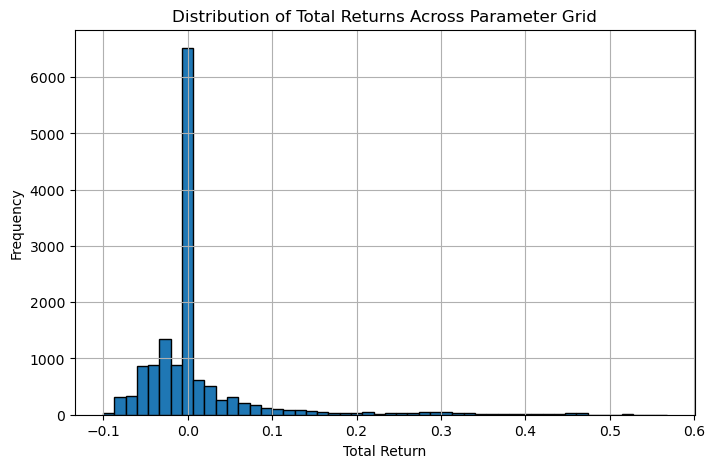

In [27]:
flat_returns = reshaped.flatten()
# Studying the distribution of total returns

plt.figure(figsize=(8, 5))
plt.hist(flat_returns, bins=50, edgecolor='black')
plt.title("Distribution of Total Returns Across Parameter Grid")
plt.xlabel("Total Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


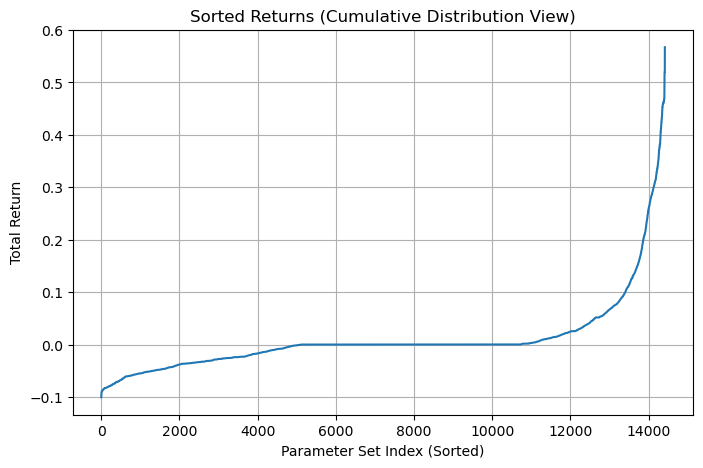

In [28]:
# Studying the distribution of returns
sorted_returns = np.sort(flat_returns)

plt.figure(figsize=(8, 5))
plt.plot(sorted_returns)
plt.title("Sorted Returns (Cumulative Distribution View)")
plt.xlabel("Parameter Set Index (Sorted)")
plt.ylabel("Total Return")
plt.grid(True)
plt.show()


In [ ]:
def crop_with_padding(grid: np.ndarray, pad: int = 3) -> tuple:
    """
    Crops a NumPy array by removing zero-only margins and leaves padding in all dimensions.

    Parameters:
        grid (np.ndarray): Input N-dimensional array.
        pad (int): Number of elements to retain as padding after the non-zero boundary.

    Returns:
        cropped_grid (np.ndarray): Cropped version of the input.
        slices (list of slice): List of slice objects used for cropping (for index tracking).
    """
    nonzero_mask = grid != 0
    coords = np.argwhere(nonzero_mask)

    if coords.size == 0:
        raise ValueError("Grid contains only zeros")

    min_bounds = coords.min(axis=0)
    max_bounds = coords.max(axis=0) + 1  # Inclusive

    # Apply padding and clip to bounds
    slices = []
    for dim in range(grid.ndim):
        start = max(min_bounds[dim] - pad, 0)
        end = min(max_bounds[dim] + pad, grid.shape[dim])
        slices.append(slice(start, end))

    # Slice the grid
    cropped_grid = grid[tuple(slices)]
    return cropped_grid, slices


[14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]


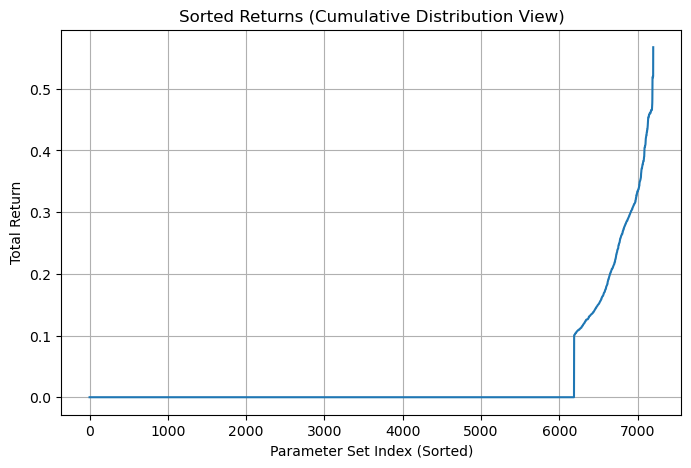

In [ ]:
threshold = 0.1
filtered_grid = np.where(reshaped >= threshold, reshaped, 0)
cropped_grid, slices = crop_with_padding(filtered_grid, pad=smoothing_size)

cropped_rsi = rsi_periods[slices[0]]
cropped_entry = entry_thresholds[slices[1]]
cropped_exit = exit_thresholds[slices[2]]


flat_filtered_cropped_returns = cropped_grid.flatten()
sorted_filtered_cropped_returns = np.sort(flat_filtered_cropped_returns)

plt.figure(figsize=(8, 5))
plt.plot(sorted_filtered_cropped_returns)
plt.title("Sorted Returns (Cumulative Distribution View)")
plt.xlabel("Parameter Set Index (Sorted)")
plt.ylabel("Total Return")
plt.grid(True)
plt.show()


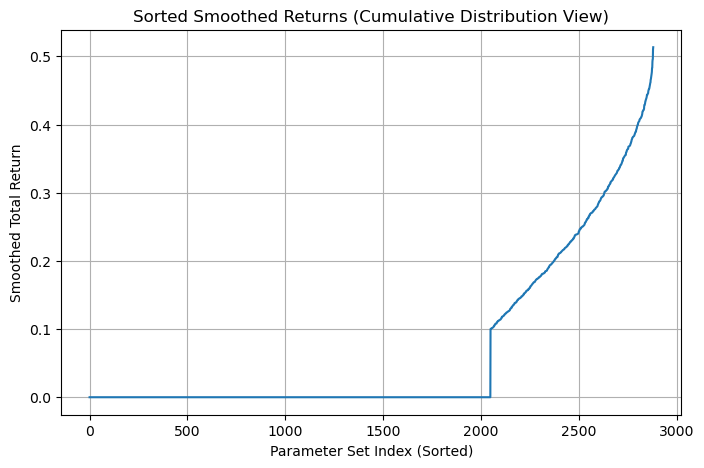

In [31]:
smoothed_grid = uniform_filter(cropped_grid, size=smoothing_size) # 3x smoothing in every dimension
# Could potentially imporve this using GPU and a different method


final_filtered_grid = np.where(smoothed_grid >= 0.1, smoothed_grid, 0.0)
final_cropped_grid, slices = crop_with_padding(final_filtered_grid, pad=1)
final_rsi = cropped_rsi[slices[0]]
final_entry = cropped_entry[slices[1]]
final_exit = cropped_exit[slices[2]]


flat_smoothed_returns = final_cropped_grid.flatten()
sorted_smoothed_returns = np.sort(flat_smoothed_returns)


plt.figure(figsize=(8, 5))
plt.plot(sorted_smoothed_returns)
plt.title("Sorted Smoothed Returns (Cumulative Distribution View)")
plt.xlabel("Parameter Set Index (Sorted)")
plt.ylabel("Smoothed Total Return")
plt.grid(True)
plt.show()

In [32]:
print(final_cropped_grid.shape, cropped_rsi)

best_index = np.unravel_index(np.argmax(final_cropped_grid), final_cropped_grid.shape)
best_rsi = cropped_rsi[best_index[0]]
best_entry = cropped_entry[best_index[1]]
best_exit = cropped_exit[best_index[2]]

print(f"🔥 Best stable combo: RSI={best_rsi}, Entry={best_entry}, Exit={best_exit}")
print(f"Estimated Return at that combo: {smoothed_grid[best_index]:.4f}")

(15, 12, 16) [14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
🔥 Best stable combo: RSI=28, Entry=23, Exit=76
Estimated Return at that combo: 0.0000


In [33]:
cropped_params = {
    'RSI_rsi_period': cropped_rsi[slices[0]],
    'RSI_entry_threshold': cropped_entry[slices[1]],
    'RSI_exit_threshold': cropped_exit[slices[2]]
}

# Step 1: Get best index in the cropped/smoothed grid
best_index = np.unravel_index(np.argmax(final_cropped_grid), final_cropped_grid.shape)

# Step 2: Use that index to extract parameter values
best_params = {
    k: np.array(v)[i] for i, (k, v) in zip(best_index, cropped_params.items())
}


# Step 3: Print it
print("🔥 Best stable combo:")
for k, v in best_params.items():
    print(f"  {k} = {v}")

print(f"Estimated Return at that combo: {smoothed_grid[best_index]:.4f}")


🔥 Best stable combo:
  RSI_rsi_period = 28
  RSI_entry_threshold = 35
  RSI_exit_threshold = 80
Estimated Return at that combo: 0.0000


In [34]:
best_index = np.unravel_index(np.argmax(smoothed_grid), smoothed_grid.shape)
best_rsi = cropped_rsi[best_index[0]]
best_entry = cropped_entry[best_index[1]]
best_exit = cropped_exit[best_index[2]]

print(f"🔥 Best stable combo: RSI={best_rsi}, Entry={best_entry}, Exit={best_exit}")
print(f"Estimated Return at that combo: {smoothed_grid[best_index]:.4f}")

🔥 Best stable combo: RSI=28, Entry=35, Exit=80
Estimated Return at that combo: 0.5134


In [35]:
# Get all parameter combinations as tuples
index = pd.MultiIndex.from_product(
    [final_rsi, final_entry, final_exit],
    names=["RSI_rsi_period", "RSI_entry_threshold", "RSI_exit_threshold"]
)

# Flatten the smoothed grid
flat_final_values = final_cropped_grid.flatten()

# Create a Series with MultiIndex
final_series = pd.Series(flat_final_values, index=index)

fig = final_series.vbt.volume(
    x_level="RSI_entry_threshold",
    y_level="RSI_exit_threshold",
    z_level="RSI_rsi_period",
    title="Final Smoothed + Filtered RSI Return Volume",
    xaxis_title="Entry Threshold",
    yaxis_title="Exit Threshold",
    coloraxis_colorbar=dict(title="Smoothed Return")
)
fig.show()


🔥 As predicted:

Best stable combo: RSI=28, Entry=35, Exit=80

Estimated Return at that combo: 0.5134

Critiques:

1) these "returns" approximate the real, they are averaged locally

(they at least tell us where, which is more important since we might have abstract colour values due to abstract optimisation function)

2) All metrics are treated equally, we arent looking at sharpe or max drawndown, etc

(easy to fix with abstract constraints)

3) No discretenization across time, or market regines, what works well during one period might change, and even if it was optimal, for those conditions ei a bullish market or other, it might get overshadowed by more long term strats of lower performance

(Good to consider, once we examine different market conditions and we are looking at specific time frames)

4) we havent tested on walk forward, and we chose a transaction threshold by looking at a graph, which will have to be something we always keep in mind

(Combining these problems we can tackle them together by optimising for the threshold)

In [36]:
# Finally we will compile all this into a function called:

# reduce_overfitting(smoothing_size=3, trancation_threshold=0.1)


# We can then Optimise, reduce overfitting
# then walk forward test and for these parameters 
# (most imporantly tranctation threshold) 


### Arbritrary strategy, parameters and optimisation_function if included

In [37]:
# Extract results
results = pf_opt2.total_return() # this should be flattened and look like: (len(close),)

# For abritrary conditions do results = objective_function(results)

# Extract parameters
multi_index = pf_opt2.wrapper.columns

# Extract levels and shape
param_df = pd.DataFrame(multi_index.tolist(), columns=multi_index.names)
param_levels = {col: np.unique(param_df[col]) for col in param_df.columns}
shape = tuple(len(param_levels[col]) for col in param_df.columns)

# Reshape
reshaped = results.to_numpy().reshape(shape)

print(param_df)

# Define the smoothing size
smoothing_size = 3


      Custom2_ema  Custom2_period  Custom2_entries  Custom2_exits  \
0               2               7               10             60   
1               2               7               10             60   
2               2               7               10             60   
3               2               7               10             60   
4               2               7               10             60   
...           ...             ...              ...            ...   
8635           22              28               35             85   
8636           22              28               35             85   
8637           22              28               35             85   
8638           22              28               35             85   
8639           22              28               35             85   

      Custom2_sl_trail  Custom2_tp_stop  Custom2_sl_stop  
0                 0.01             0.01             0.05  
1                 0.01             0.06             0

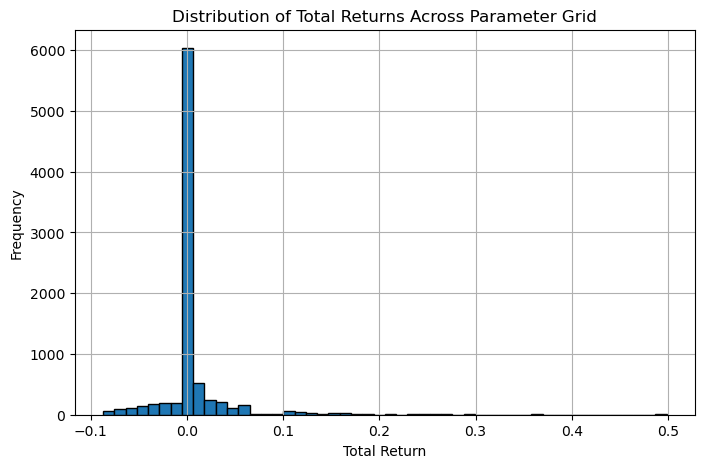

In [39]:
# Wont be neccesary long term

# Studying the distribution of total returns
plt.figure(figsize=(8, 5))
plt.hist(reshaped.flatten(), bins=50, edgecolor='black')
plt.title("Distribution of Total Returns Across Parameter Grid")
plt.xlabel("Total Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


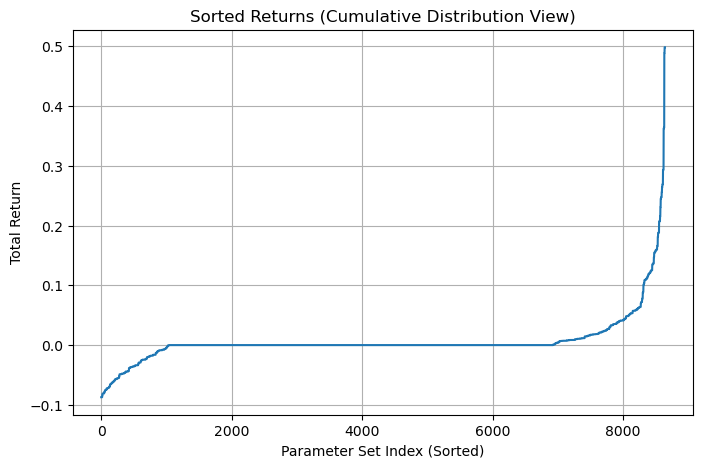

In [40]:
# Wont be neccesary long term

# Studying the distribution of returns
plt.figure(figsize=(8, 5))
plt.plot(np.sort(reshaped.flatten()))
plt.title("Sorted Returns (Cumulative Distribution View)")
plt.xlabel("Parameter Set Index (Sorted)")
plt.ylabel("Total Return")
plt.grid(True)
plt.show()


In [41]:
def crop_with_padding(grid: np.ndarray, pad: int = 3) -> tuple:
    """
    Crops a NumPy array by removing zero-only margins and leaves padding in all dimensions.

    Parameters:
        grid (np.ndarray): Input N-dimensional array.
        pad (int): Number of elements to retain as padding after the non-zero boundary.

    Returns:
        cropped_grid (np.ndarray): Cropped version of the input.
        slices (list of slice): List of slice objects used for cropping (for index tracking).
    """
    nonzero_mask = grid != 0
    coords = np.argwhere(nonzero_mask)

    if coords.size == 0:
        raise ValueError("Grid contains only zeros")

    min_bounds = coords.min(axis=0)
    max_bounds = coords.max(axis=0) + 1  # Inclusive

    # Apply padding and clip to bounds
    slices = []
    for dim in range(grid.ndim):
        start = max(min_bounds[dim] - pad, 0)
        end = min(max_bounds[dim] + pad, grid.shape[dim])
        slices.append(slice(start, end))

    # Slice the grid
    cropped_grid = grid[tuple(slices)]
    return cropped_grid, slices


In [42]:
def crop_with_padding_with_params(grid: np.ndarray, param_levels: dict, pad: int = 3):
    """
    Crop an N-D result grid to the non-zero region + optional padding,
    and extract corresponding parameter values.

    Args:
        grid (np.ndarray): N-D array of returns.
        param_levels (dict): param_name -> list/array of unique values.
        pad (int): padding around the non-zero region.

    Returns:
        cropped_grid (np.ndarray): Cropped N-D array.
        slices (list of slice): Slices used to crop.
        cropped_param_levels (dict): param_name -> trimmed list of values.
    """
    nonzero_mask = grid != 0
    coords = np.argwhere(nonzero_mask)

    if coords.size == 0:
        raise ValueError("Grid contains only zeros")

    min_bounds = coords.min(axis=0)
    max_bounds = coords.max(axis=0) + 1  # inclusive

    slices = []
    cropped_param_levels = {}

    for i, (param_name, values) in enumerate(param_levels.items()):
        start = max(min_bounds[i] - pad, 0)
        end = min(max_bounds[i] + pad, len(values))

        slices.append(slice(start, end))
        cropped_param_levels[param_name] = values[start:end]

    cropped_grid = grid[tuple(slices)]
    return cropped_grid, slices, cropped_param_levels


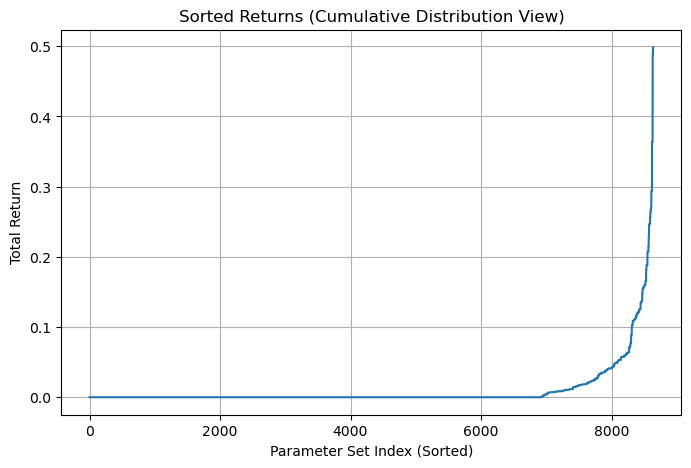

In [43]:
threshold = 0.0

filtered_results = np.where(reshaped > threshold, reshaped, 0)

cropped_results, slices = crop_with_padding(filtered_results, pad=smoothing_size) #this has a padding effect that the next line doesnt

cropped_grid, slices, cropped_param_levels = crop_with_padding_with_params(filtered_results, param_levels, smoothing_size)
#nonzero_cropped = cropped_results[cropped_results > 0]


plt.figure(figsize=(8, 5))
plt.plot(np.sort(cropped_grid.flatten()))
plt.title("Sorted Returns (Cumulative Distribution View)")
plt.xlabel("Parameter Set Index (Sorted)")
plt.ylabel("Total Return")
plt.grid(True)
plt.show()


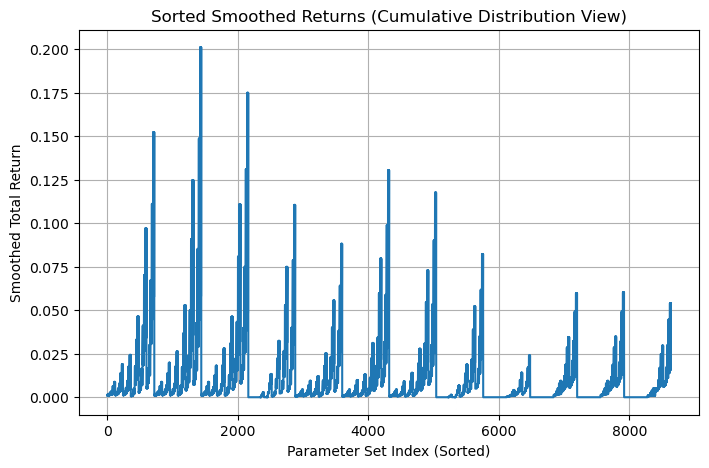

In [44]:
smoothed_grid = uniform_filter(cropped_grid, size=smoothing_size) # 3x smoothing in every dimension
# Could potentially imporve this using GPU and a different method

sorted_smoothed_returns = np.sort(smoothed_grid)


plt.figure(figsize=(8, 5))
plt.plot(sorted_smoothed_returns.flatten())
plt.title("Sorted Smoothed Returns (Cumulative Distribution View)")
plt.xlabel("Parameter Set Index (Sorted)")
plt.ylabel("Smoothed Total Return")
plt.grid(True)
plt.show()


#This graph is unsorted but i like how u can intepret how some values are better than others we just dont know which yet

In [45]:
#this kinda gets the density but mb we can do better

def get_best_param_combo(grid, param_levels, slices):
    """
    Find the best-performing parameter combo from a smoothed or cropped grid.

    Args:
        grid (np.ndarray): The N-D result grid (e.g., after smoothing or cropping).
        param_levels (dict): Original full parameter levels (param name -> list of values).
        slices (list of slice): Slice objects used to crop param_levels to match grid.

    Returns:
        best_params (dict): Best parameter combination.
        best_value (float): Value at that combination in the grid.
    """
    best_index = np.unravel_index(np.argmax(grid), grid.shape)
    param_names = list(param_levels.keys())

    best_params = {}
    for i, name in enumerate(param_names):
        values = param_levels[name]
        sl = slices[i]
        sliced_values = values[sl]  # Apply cropping
        best_params[name] = sliced_values[best_index[i]]

    best_value = grid[best_index]
    return best_params, best_value


best_params, best_return = get_best_param_combo(smoothed_grid, param_levels, slices)

print("🔥 Best stable combo:")
for k, v in best_params.items():
    print(f"  {k} = {v}")
print(f"Estimated Return at that combo: {best_return:.4f}")


🔥 Best stable combo:
  Custom2_ema = 2
  Custom2_period = 14
  Custom2_entries = 35
  Custom2_exits = 85
  Custom2_sl_trail = 0.01
  Custom2_tp_stop = 0.16000000000000003
  Custom2_sl_stop = 0.05
Estimated Return at that combo: 0.2011


In [46]:
import pandas as pd
from itertools import product

def make_score_series_from_grid(grid, param_levels):
    """
    Convert N-D grid to Series with MultiIndex matching parameter levels.

    Args:
        grid (np.ndarray): N-D result array (e.g. smoothed_grid)
        param_levels (dict): param_name -> list of values (cropped or full)

    Returns:
        pd.Series with MultiIndex
    """
    param_names = list(param_levels.keys())
    param_values = list(param_levels.values())
    combos = list(product(*param_values))  # Cartesian product

    flat = grid.flatten()
    index = pd.MultiIndex.from_tuples(combos, names=param_names)

    return pd.Series(flat, index=index)


alt_scores = make_score_series_from_grid(smoothed_grid, cropped_param_levels)

best_index = alt_scores.idxmax()
best_portfolio = pf_opt2[best_index]

best_portfolio.plot(title="🔥 Best by Custom Smoothed Return").show()



### Streamlined Version for General Use

I've realised logically, best way to do this is, first to smooth/avg, then filter, then crop, we want input to be results df, and output to be the same, and parameter spaces, then we can easily plot the  best stable parameters

In [65]:
def Overfitting_reduction(pf, objective_function=None, smoothing_size=3, filter_threshold=0.0):
    # Step 1: Compute raw result grid
    if objective_function is not None:
        results = objective_function(pf)
    else:
        results = pf.total_return().values

    # Step 2: Extract parameter structure
    multi_index = pf.wrapper.columns
    param_df = pd.DataFrame(multi_index.tolist(), columns=multi_index.names)
    param_levels = {col: np.unique(param_df[col]) for col in param_df.columns}
    shape = tuple(len(param_levels[col]) for col in param_df.columns)

    # Step 3: Reshape results
    reshaped = results.reshape(shape)

    # Step 4: Smooth
    smoothed_grid = uniform_filter(reshaped, size=smoothing_size)

    # Step 5: Filter
    filtered_grid = np.where(smoothed_grid > filter_threshold, smoothed_grid, 0.0)

    # Step 6: Crop grid and adjust parameter levels
    final_grid, slices, cropped_param_levels = crop_with_padding_with_params(filtered_grid, param_levels, pad=smoothing_size)

    # Step 7: Build MultiIndex Series from N-D grid
    param_names = list(cropped_param_levels.keys())
    param_values = list(cropped_param_levels.values())
    combos = list(product(*param_values))  # Cartesian product
    score_series = pd.Series(final_grid.flatten(), index=pd.MultiIndex.from_tuples(combos, names=param_names))

    # Step 8: Get best parameters and portfolio
    best_param_tuple = score_series.idxmax()
    best_value = score_series.loc[best_param_tuple]
    best_portfolio = pf[best_param_tuple]
    best_params = dict(zip(param_names, best_param_tuple))

    return best_params, best_value, best_portfolio


best_params, best_value, best_pf = Overfitting_reduction(pf_opt2, objective_function=None, smoothing_size=3, filter_threshold=0.0)

for k, v in best_params.items():
    print(f"{k} = {v}")
print(f"Estimated best stable return with these parameters: {best_value:.4f}")

best_pf.plot(title="🔥 Best by Custom Smoothed Return").show()



Custom2_ema = 2
Custom2_period = 14
Custom2_entries = 35
Custom2_exits = 85
Custom2_sl_trail = 0.01
Custom2_tp_stop = 0.16000000000000003
Custom2_sl_stop = 0.05
Estimated best stable return with these parameters: 0.2006


# next part i wanna do is basic rsi, fixed sl, trailing_sl and tp but variable entry and exit, we base it one 3 days bt optimised, 1 day walk forward, we then track our parameter space evolution, mb we even do a metric space collapse for easier visual intepretetion

step 1 get data, 2) divide it up, 3)test iteretavily(walk-forward) and record both reults, and parameters, 4) look at parameter evolution, and look at the final equity curve

In [ ]:
# also wanna do a couple things so we fix the sl and tp say 1:2, optimise for entries and exits for max returns on rsi, then we test another sl and tp ratio say 1:5, then we do an ema with variable window instead of rsi. test all these over 1 yr, on min timefram, 3 day backtest, 1 day updates.

# Other forms of Strategy Validation

Ideas: 
1) walk forward test
2) monte carlo 
3) Statistical tests
4) parameter sensitivity??
5) regime testing
6) edge or alpha decay 
7) robustness check

# Market Scanner

# I think the next sections can wait since they can get quite hard

# Time Sereies embedding and Evolving Dynamical Systems modelling, Signal PRocessing (probably best for sideways markets)